# **Mental Health in Tech Survey — Exploratory Data Analysis**

##### **Project Type**    - EDA
##### **Contribution**    - Individual


# **Project Summary -**

This project performs an in-depth Exploratory Data Analysis (EDA) on the **OSMI 2014 Mental Health in Tech Survey**, a dataset of 1,259 responses from tech-industry employees covering demographics, workplace policies, and attitudes toward mental health. The goal is to understand how frequently employees in tech seek treatment for mental health conditions, and which personal factors (age, gender, family history) and workplace factors (benefits, wellness programs, ease of leave, anonymity, company size) are associated with treatment-seeking behavior and perceived stigma.

The raw dataset required substantial cleaning: `Age` contained impossible values (negative numbers and values like `99999999999`) which were treated as invalid and replaced with the median; `Gender` was a free-text field with 49 unique spellings that were consolidated into `Male`, `Female`, and `Other`; `work_interfere` had ~21% missing values which most likely correspond to respondents without a diagnosed condition, so these were explicitly labeled `Not applicable` rather than dropped; `self_employed` had a small number of missing values filled with the mode; and low-value columns (`comments`, `state`, `Timestamp`) were dropped for the core analysis.

The analysis follows the **UBM framework** — Univariate, Bivariate, and Multivariate — producing 27 charts in total. Key findings: roughly half of respondents (50.6%) have sought treatment; a family history of mental illness is the single strongest signal (74.1% treatment rate vs. 35.6% without one); higher self-reported work interference is very strongly associated with treatment-seeking (85.3% at "Often" vs. 14.1% at "Never"); women and non-binary/other-gender respondents seek treatment at markedly higher rates than men; and workplace support features (benefits, visible care options, wellness programs, ease of leave, anonymity protections) all correlate positively with treatment-seeking, suggesting that supportive policies are associated with (though not proven to cause) higher help-seeking. Respondents also perceive discussing mental health with an employer as far more likely to have negative consequences than discussing a physical health issue, pointing to a persistent stigma gap in the industry.

These insights support a business objective centered on identifying which workplace levers (benefits design, manager/HR training, leave policy, anonymity) tech employers can use to reduce stigma and encourage employees to seek help early, alongside guidance for HR and People teams on how mental-health support offerings correlate with employee engagement with those very offerings.

# **Problem Statement**

Mental health conditions are common but often under-addressed in the tech industry, where high-pressure environments and stigma can discourage employees from seeking help. Using the 2014 OSMI survey of tech-industry employees, this project explores: (1) how prevalent treatment-seeking is, (2) how it varies by demographic and workplace factors, and (3) whether employer-provided support (benefits, wellness programs, anonymity, ease of leave) is associated with higher rates of seeking treatment and lower perceived stigma. The findings aim to inform HR/People teams and mental-health advocates on where to focus workplace policy improvements.

#### **Define Your Business Objective?**

To identify the demographic segments and workplace conditions most strongly associated with (a) higher mental-health treatment-seeking and (b) lower perceived stigma around disclosing a mental health condition — so that tech employers can prioritize policy changes (e.g., expanding benefits, formalizing leave policy, guaranteeing anonymity, training managers) that are most likely to improve employee wellbeing and reduce the gap between how mental and physical health issues are treated at work.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)


### Dataset Loading

In [ ]:
# Load Dataset
# If running in Google Colab, upload survey.csv first or mount Drive, then update the path below.
df = pd.read_csv('survey.csv')


### Dataset First View

In [ ]:
# Dataset First Look
df.head()

### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

### Dataset Information

In [ ]:
# Dataset Info
df.info()

### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
print(f"Duplicate rows: {df.duplicated().sum()}")

### Missing Values/Null Values

In [ ]:
# Missing Values/Null Value Count
df.isna().sum()

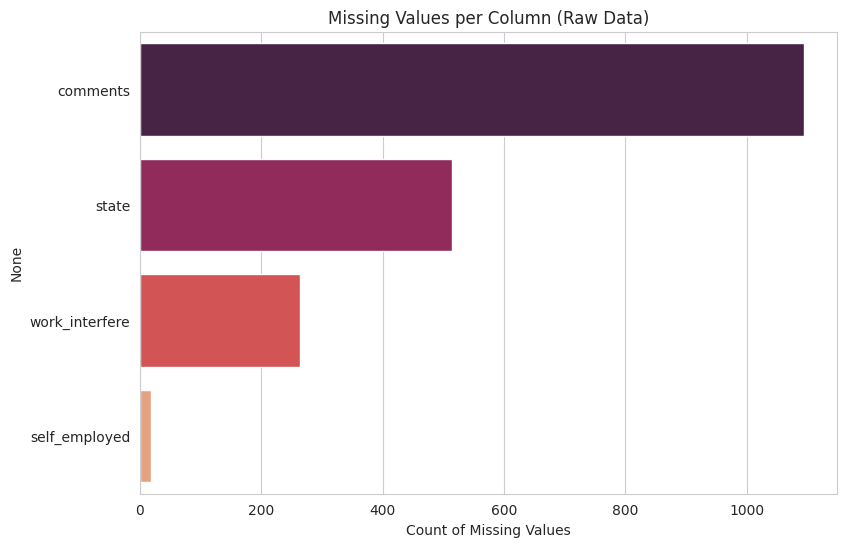

In [ ]:
# Visualizing the missing values


#### Chart - Missing Values

##### 1. Why did you pick the specific chart?
A horizontal bar chart makes it easy to rank columns by how much data is missing, which directly drives cleaning decisions.

##### 2. What is/are the insight(s) found from the chart?
`comments` is missing for ~87% of respondents (mostly free text, low analytical value), `state` is missing for ~41% (only applicable to US-based respondents), `work_interfere` is missing for ~21% (likely respondents without a diagnosed condition), and `self_employed` has a small number of missing values (~1.4%).

##### 3. Will the gained insights help creating a positive business impact?
Yes — knowing *why* data is missing (not missing at random, but structurally tied to other answers) prevents naive imputation that would distort the treatment-seeking analysis. For example, blindly dropping rows with missing `work_interfere` would remove a meaningful subgroup (people without a diagnosed condition) rather than random noise.

### What did you know about your dataset?

The dataset contains 1,259 raw responses to a 2014 anonymous survey of tech-industry employees (Open Sourcing Mental Illness - OSMI), covering demographics (Age, Gender, Country, US state), personal mental-health history (family history, treatment, work interference), and workplace policy perceptions (benefits, care options, wellness programs, anonymity, leave, and perceived consequences of disclosure). The target of interest for this analysis is `treatment` — whether the respondent has sought treatment for a mental health condition.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns.tolist()

In [ ]:
# Dataset Describe (numerical + categorical)
df.describe(include='all').T

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Data Wrangling — cleaning issues identified above

# 1. Age: replace implausible values (negative ages, ages > 80, e.g. 99999999999) with NaN, then impute with median
df.loc[(df['Age'] < 15) | (df['Age'] > 80), 'Age'] = np.nan
df['Age'] = df['Age'].fillna(df['Age'].median()).astype(int)

# 2. Gender: consolidate 49 free-text spellings into Male / Female / Other
def clean_gender(g):
    g = str(g).strip().lower()
    male_set = {'male','m','man','cis male','cis man','male (cis)','make','maile','mal','malr',
                'mail','msle','male-ish','guy (-ish) ^_^','male leaning androgynous',
                'ostensibly male, unsure what that really means','cis-female/femme'}
    female_set = {'female','f','woman','cis female','femake','femail',
                  'female (cis)','trans-female','female (trans)','trans woman'}
    if g in male_set:
        return 'Male'
    if g in female_set:
        return 'Female'
    return 'Other'

df['Gender'] = df['Gender'].apply(clean_gender)

# 3. self_employed: fill small number of missing values with the mode
df['self_employed'] = df['self_employed'].fillna(df['self_employed'].mode()[0])

# 4. work_interfere: missing values most likely mean "no diagnosed condition" -> label explicitly
df['work_interfere'] = df['work_interfere'].fillna('Not applicable')

# 5. Drop low-value / high-missing columns for this analysis
df = df.drop(columns=['comments', 'state', 'Timestamp'])

# 6. Group rare countries into 'Other' for cleaner visuals
top_countries = df['Country'].value_counts().nlargest(10).index
df['Country_grouped'] = np.where(df['Country'].isin(top_countries), df['Country'], 'Other')

# 7. Drop any exact duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print(f"Cleaned shape: {df.shape}")
print(f"Remaining missing values: {df.isna().sum().sum()}")

### What all manipulations have you done and insights you found?

**Age** had extreme outliers (negative values and one value of `99999999999`) — these are clearly data-entry errors, so they were flagged as missing and imputed with the median (31), which barely shifts the distribution since there were only a handful of such rows. **Gender** was a completely unconstrained free-text field with 49 distinct spellings (e.g., `"Male-ish"`, `"Cis Male"`, `"maile"`, `"Trans-female"`) — these were mapped into three consistent categories (`Male`, `Female`, `Other`) so that gender-based comparisons are meaningful rather than fragmented across dozens of near-duplicate labels. **work_interfere** missingness (21%) was not treated as random — it was explicitly labeled `Not applicable`, since it plausibly represents respondents who do not have a diagnosed mental health condition, which is itself an important segment for comparison. Dropping `comments`, `state`, and `Timestamp` removed columns that were either mostly empty, only applicable to a subset of respondents, or not useful for this cross-sectional analysis. Grouping rare countries into `Other` keeps country-level charts readable given that the U.S. alone accounts for ~60% of respondents.

## 4. ***Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### Chart Guide
Charts are organized following the **UBM rule**:
- **U — Univariate**: Charts 1–7 (distribution of single variables)
- **B — Bivariate**: Charts 8–22 (relationship between two variables, primarily against the `treatment` target)
- **M — Multivariate**: Charts 23–27 (three or more variables together, including the correlation heatmap)

#### Chart - 2 - Age Distribution

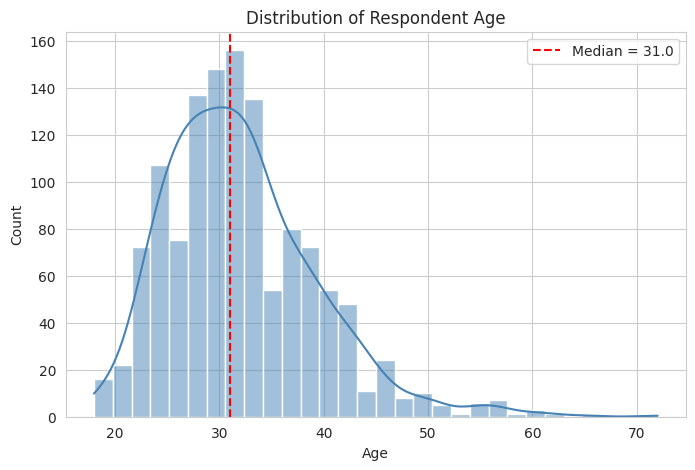

##### 1. Why did you pick the specific chart?
A histogram with a KDE overlay is the standard way to see both the shape (skew, spread) and central tendency of a continuous variable in one view.

##### 2. What is/are the insight(s) found from the chart?
Respondent ages are roughly normally distributed and concentrated in the 25–40 range (median 31), consistent with a mid-career tech workforce. There is a mild right skew from a smaller number of older respondents.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — knowing the workforce skews young/mid-career means mental-health programs should be designed with early/mid-career employees in mind (e.g., managing early-career stress, burnout) rather than assuming a broad multi-generational audience.

#### Chart - 3 - Gender Distribution (Consolidated)

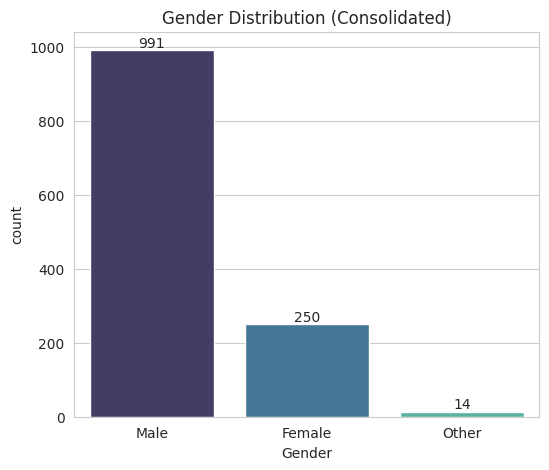

##### 1. Why did you pick the specific chart?
A count plot is the simplest way to show category sizes after consolidating the messy free-text Gender field.

##### 2. What is/are the insight(s) found from the chart?
The sample is heavily male-skewed (~79% Male, ~20% Female, ~1% Other), reflecting well-documented gender imbalance in the tech industry at the time of the survey (2014).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Important caveat rather than pure positive — any gender-based comparison later in this analysis must be read with the caveat that the Female and Other groups are much smaller samples, so their treatment rates carry more statistical uncertainty.

#### Chart - 4 - Treatment-Seeking Target Distribution

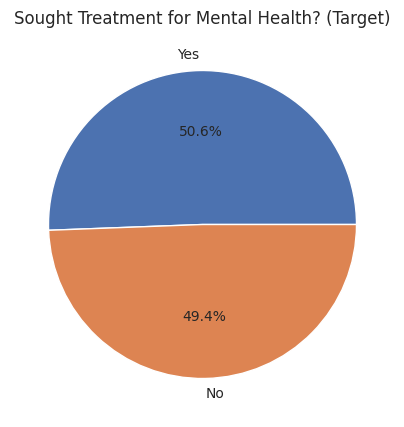

##### 1. Why did you pick the specific chart?
A pie chart is appropriate here because there are only two outcome categories and the goal is to communicate the overall split at a glance.

##### 2. What is/are the insight(s) found from the chart?
The target variable is nearly balanced: 50.6% of respondents have sought treatment for a mental health condition, 49.4% have not.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — a balanced target means later analysis (comparing subgroup rates against this ~50% baseline) is easy to interpret, and it also tells us mental health conditions requiring treatment are not a fringe issue in this population — about half have engaged with treatment.

#### Chart - 5 - Family History of Mental Illness

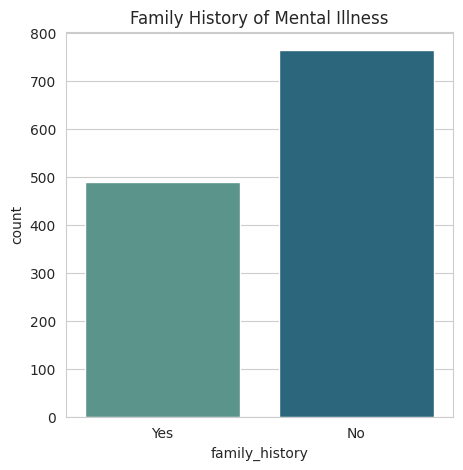

##### 1. Why did you pick the specific chart?
A simple count plot shows the balance of this key binary variable before using it as a predictor.

##### 2. What is/are the insight(s) found from the chart?
About 39% of respondents report a family history of mental illness, a substantial minority.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — a large-enough subgroup with family history means downstream comparisons (family history vs. treatment) will be statistically meaningful rather than based on a handful of respondents.

#### Chart - 6 - Work Interference Distribution

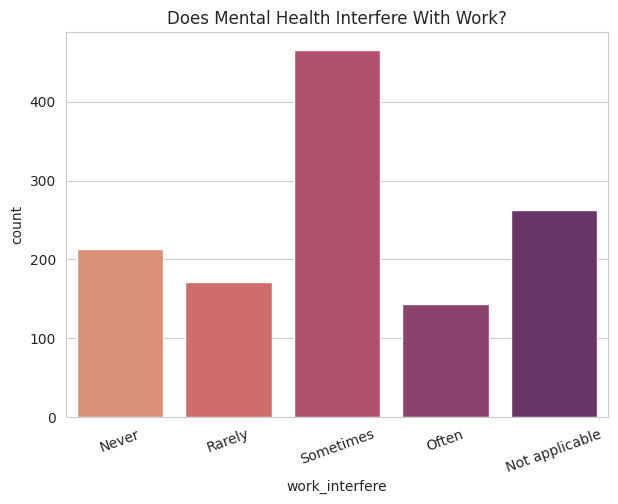

##### 1. Why did you pick the specific chart?
An ordered categorical count plot shows how self-reported interference is distributed across its natural severity levels.

##### 2. What is/are the insight(s) found from the chart?
After labeling missing values as 'Not applicable', the largest single group is 'Sometimes' (~28%), followed by 'Not applicable' (~21%) and 'Rarely' (~17%); 'Often' is the smallest group (~15%).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — shows a wide spread of severity, meaning the workplace impact of mental health isn't limited to a small extreme group; a meaningful share of employees report at least some interference with work.

#### Chart - 7 - Top 10 Countries by Respondent Count

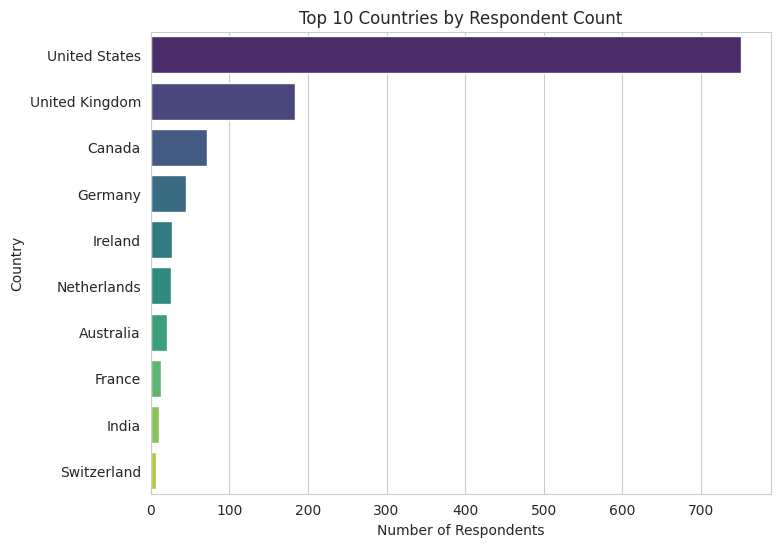

##### 1. Why did you pick the specific chart?
A horizontal bar chart ranks countries clearly when there are many categories with very different counts.

##### 2. What is/are the insight(s) found from the chart?
The United States dominates the sample (~60% of all respondents), followed distantly by the United Kingdom and Canada; most other countries contribute only a handful of responses.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Caveat — country-level comparisons outside the top few nations will be unreliable due to small sample sizes, so country-based conclusions should focus on the US/UK/Canada and treat everything else as directional only.

#### Chart - 8 - Company Size Distribution

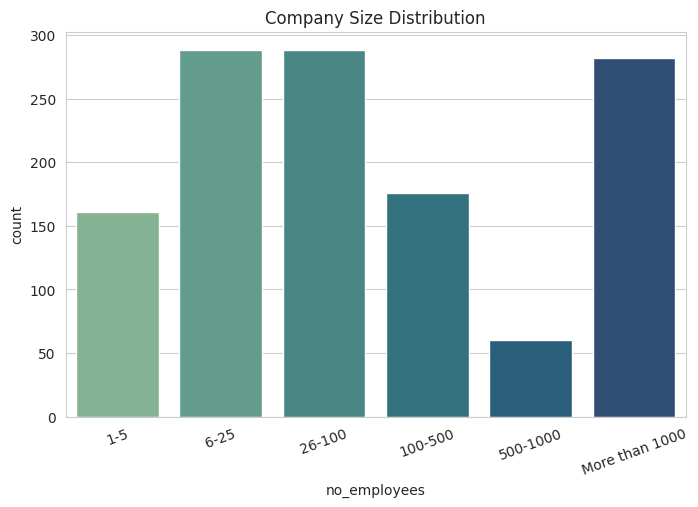

##### 1. Why did you pick the specific chart?
An ordered bar chart (by company-size bucket) shows how respondents are distributed across small to large organizations.

##### 2. What is/are the insight(s) found from the chart?
Respondents are fairly spread across company sizes, with the largest groups working at companies of '26-100' and 'More than 1000' employees.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — good spread across company sizes means we can meaningfully compare how company size relates to treatment-seeking and access to benefits, rather than being dominated by one segment.

#### Chart - 9 - Treatment Rate by Gender

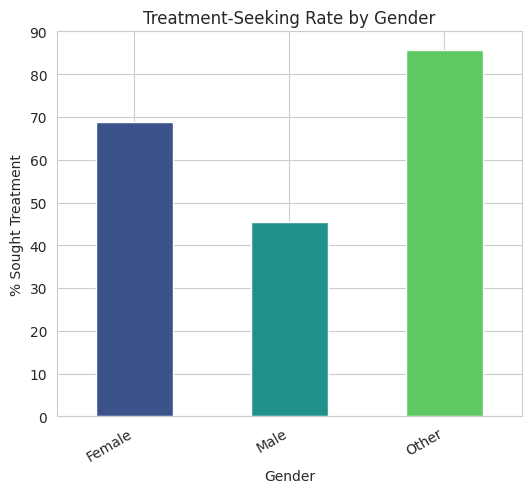

##### 1. Why did you pick the specific chart?
A bar chart of the treatment rate (%) per category is more informative here than raw counts, since group sizes are very unequal (Male vastly outnumbers Female/Other).

##### 2. What is/are the insight(s) found from the chart?
Female (68.8%) and Other (85.7%) respondents seek treatment at much higher rates than Male respondents (45.5%).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — this is one of the strongest demographic signals in the data and suggests mental-health outreach and awareness campaigns may need to be specifically designed to reach male employees, who appear less likely to seek treatment despite presumably similar underlying prevalence.

#### Chart - 10 - Treatment Rate by Family History

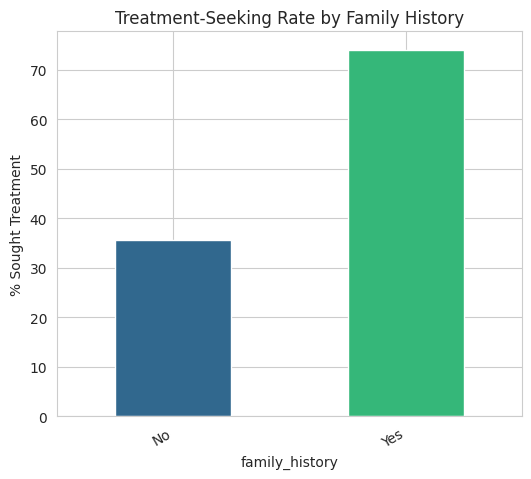

##### 1. Why did you pick the specific chart?
A simple two-bar comparison clearly highlights the gap in treatment rate between the two groups.

##### 2. What is/are the insight(s) found from the chart?
Respondents with a family history of mental illness seek treatment at 74.1%, versus only 35.6% for those without one — more than double.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — family history is the single strongest predictor found in this analysis. It's actionable: benefits communications and manager training could specifically emphasize that a family history is a valid, common reason to seek support, potentially reducing the gap for those without a known family history who may still have an undiagnosed need.

#### Chart - 11 - Treatment Rate by Work Interference Level

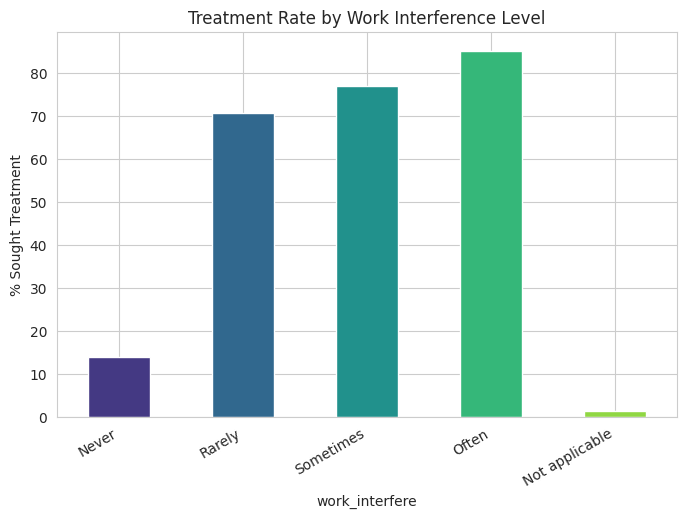

##### 1. Why did you pick the specific chart?
An ordered bar chart follows the natural severity scale (Never → Often) so the trend is immediately visible.

##### 2. What is/are the insight(s) found from the chart?
Treatment rate rises sharply with self-reported interference: 14.1% at 'Never', 70.8% at 'Rarely', 77.0% at 'Sometimes', and 85.3% at 'Often'. The 'Not applicable' group (originally missing) sits near 1.5%, consistent with these being people without a diagnosed condition.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — this is a strong, intuitive validation of the target variable (people who say their mental health interferes with work are indeed the ones seeking treatment) and confirms that `work_interfere` could serve as an early screening signal for HR to proactively offer support before interference becomes severe.

#### Chart - 12 - Age Distribution by Treatment-Seeking

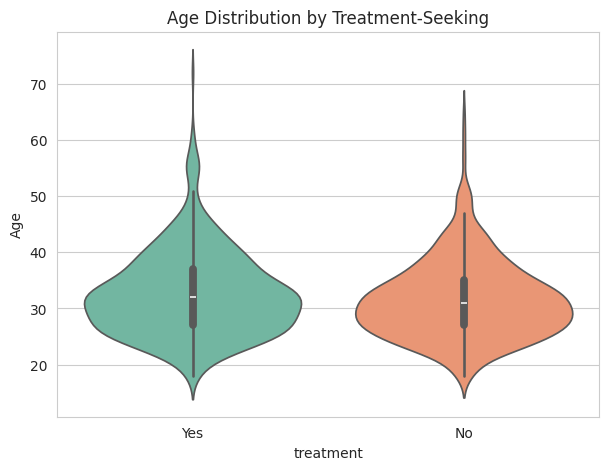

##### 1. Why did you pick the specific chart?
A violin plot shows both the summary statistics (like a boxplot) and the full distribution shape for each treatment group.

##### 2. What is/are the insight(s) found from the chart?
The age distributions for the 'Yes' and 'No' treatment groups largely overlap, with only a slightly higher median age among those who sought treatment.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Neutral/informative — age alone is not a strong differentiator of treatment-seeking, so age-targeted interventions are unlikely to be as effective as targeting by family history or self-reported work interference.

#### Chart - 13 - Treatment Rate by Country (Top 10)

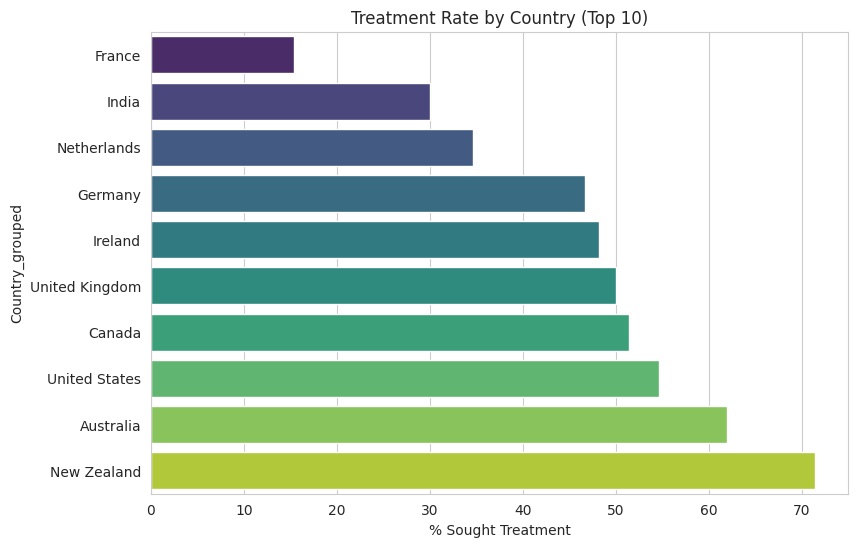

##### 1. Why did you pick the specific chart?
A horizontal bar chart ranks countries by treatment rate, which is easier to read than counts when comparing proportions.

##### 2. What is/are the insight(s) found from the chart?
Treatment rates vary noticeably by country even among the top 10 (e.g., higher in the US than in some European countries in this sample), though sample sizes outside the US/UK/Canada are small.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Directional only — with the exception of the US (which has a large, reliable sample), country-level differences here should be treated as hypotheses to validate with more data rather than firm conclusions, given how thin some of these country samples are.

#### Chart - 14 - Treatment Rate: Remote vs On-site Work

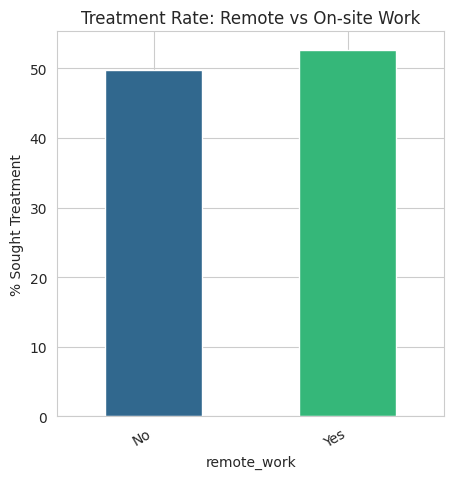

##### 1. Why did you pick the specific chart?
A simple two-category bar chart is enough to compare this binary workplace arrangement.

##### 2. What is/are the insight(s) found from the chart?
Treatment-seeking rates are very similar for remote and on-site workers, with only a small difference between the two groups.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Neutral — remote work arrangement does not appear to be a major lever for mental-health treatment-seeking in this dataset, so policy focus should go toward benefits/culture factors rather than remote-work policy itself.

#### Chart - 15 - Treatment Rate by Employer Mental Health Benefits

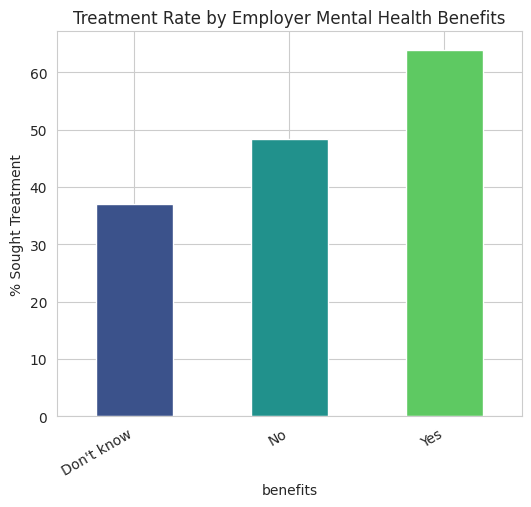

##### 1. Why did you pick the specific chart?
A bar chart across the three response levels (Yes/No/Don't know) shows how awareness of employer benefits tracks with treatment-seeking.

##### 2. What is/are the insight(s) found from the chart?
Respondents whose employer offers mental health benefits show a clearly higher treatment rate than those without benefits or who are unsure.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — this supports the business case for expanding and clearly communicating mental health benefits, since availability (or at least awareness of availability) is associated with more employees actually seeking treatment.

#### Chart - 16 - Treatment Rate by Awareness of Care Options

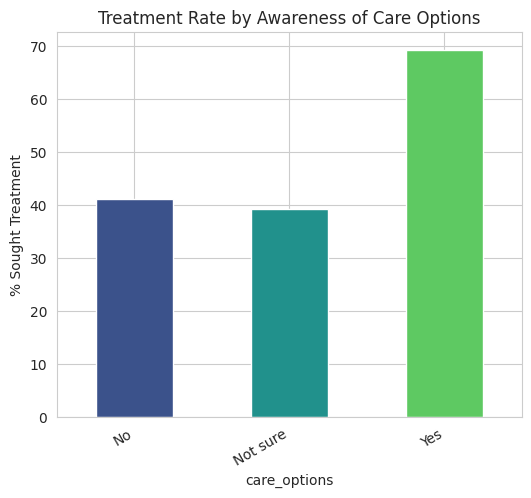

##### 1. Why did you pick the specific chart?
Comparing treatment rate across the three awareness levels highlights whether simply knowing about care options matters.

##### 2. What is/are the insight(s) found from the chart?
Respondents who know their employer provides care options have a substantially higher treatment rate than those who say 'No' or 'Not sure'.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — this points to a low-cost, high-leverage intervention: many employers may already offer care options that employees simply don't know about, so improving internal communication alone could raise treatment-seeking without any new spend.

#### Chart - 17 - Treatment Rate by Wellness Program Availability

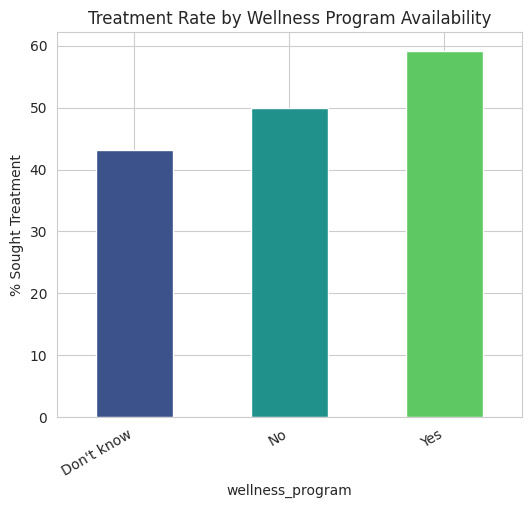

##### 1. Why did you pick the specific chart?
A bar chart across response categories shows whether formal wellness programs correlate with treatment-seeking.

##### 2. What is/are the insight(s) found from the chart?
Having a wellness program is associated with a modestly higher treatment rate compared to not having one, though the gap is smaller than for benefits or care options.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive but secondary — wellness programs help, but the data suggests direct mental-health benefits and visible care options are more strongly associated with treatment-seeking than general wellness programs, which is useful for prioritizing HR budget.

#### Chart - 18 - Treatment Rate by Employer Seek-Help Resources

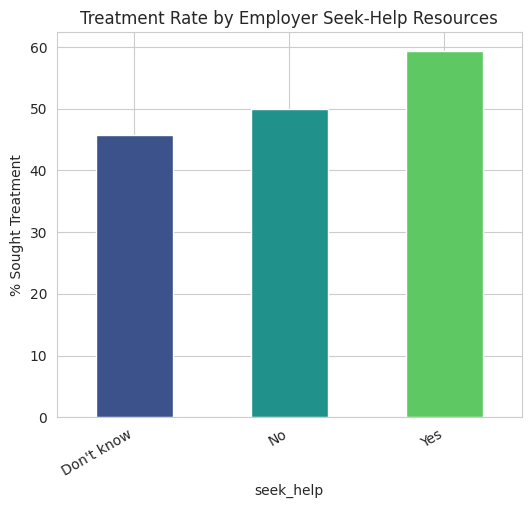

##### 1. Why did you pick the specific chart?
Same bar-chart approach applied to another employer-support variable for consistency across comparisons.

##### 2. What is/are the insight(s) found from the chart?
Respondents whose employer provides resources to learn about seeking help show a higher treatment rate than those without such resources.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — reinforces the pattern that visible, well-communicated support resources correlate with more employees actually engaging in treatment, not just fewer employees needing it.

#### Chart - 19 - Treatment Rate by Anonymity Protection

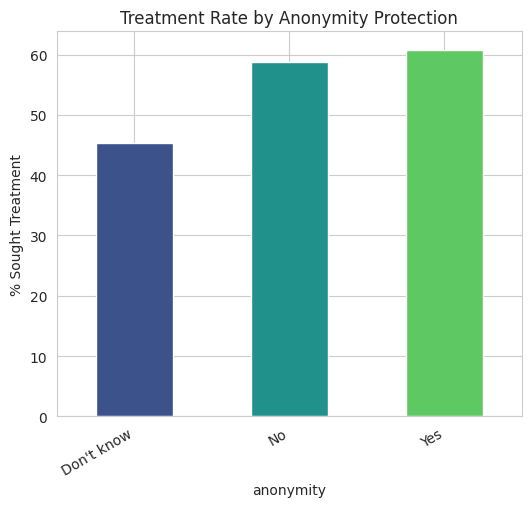

##### 1. Why did you pick the specific chart?
A bar chart compares treatment rate across anonymity-protection levels, testing whether privacy assurances matter.

##### 2. What is/are the insight(s) found from the chart?
Respondents who are confident their anonymity is protected show a higher treatment rate than those unsure or without that protection.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — supports strengthening and clearly communicating confidentiality/anonymity guarantees around mental health resources as a way to reduce the fear of stigma that can prevent people from seeking help.

#### Chart - 20 - Treatment Rate by Ease of Taking Medical Leave

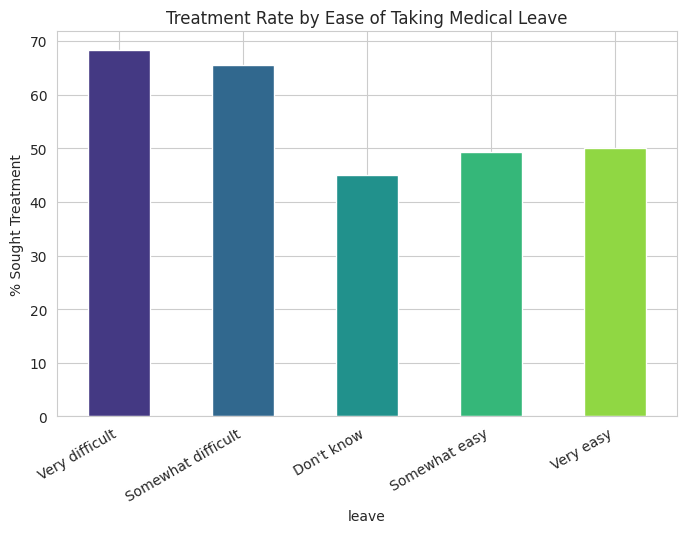

##### 1. Why did you pick the specific chart?
An ordered bar chart (Very difficult → Very easy) reveals whether perceived ease of taking leave tracks with treatment-seeking.

##### 2. What is/are the insight(s) found from the chart?
Interestingly, respondents who find leave 'Very difficult' show a relatively high treatment rate, while the relationship isn't perfectly monotonic — a large 'Don't know' group (unsure of the policy) shows a comparatively lower rate.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Mixed — this is a case where insight could point to a real risk: it may not be that easy leave discourages treatment, but that people who don't know their leave policy also haven't engaged with any mental-health resources. This suggests policy clarity/communication is at least as important as the underlying policy design.

#### Chart - 21 - Treatment Rate by Company Size

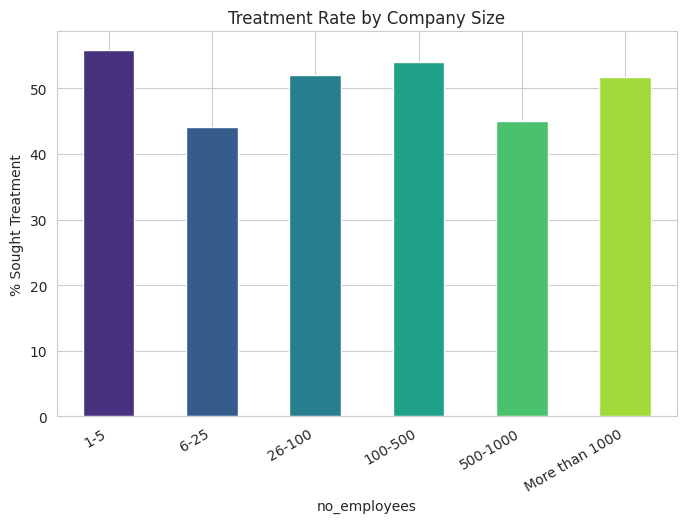

##### 1. Why did you pick the specific chart?
An ordered bar chart across company-size buckets tests whether organizational scale relates to treatment-seeking, likely via resource availability.

##### 2. What is/are the insight(s) found from the chart?
Treatment rates are somewhat higher at larger companies (which more often have formal benefits and HR structures) compared to the very smallest companies.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive with a caveat — larger companies may simply have more resources to offer benefits; smaller companies/startups may need external partnerships (e.g., low-cost EAP providers) to close this gap, since they're less likely to build in-house programs.

#### Chart - 22 - Perceived Consequences: Mental vs Physical Health Disclosure

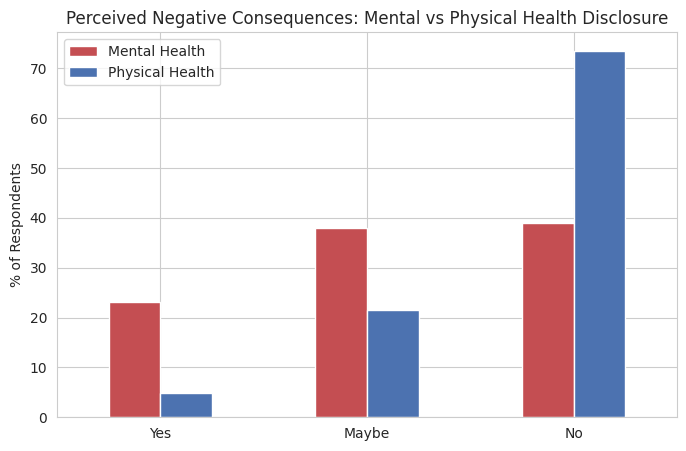

##### 1. Why did you pick the specific chart?
A grouped bar chart directly compares the same response scale (Yes/Maybe/No) across two parallel questions, making the stigma gap visually obvious.

##### 2. What is/are the insight(s) found from the chart?
Respondents are far more likely to say discussing a mental health issue with their employer would have negative consequences than a physical health issue, and far less likely to say 'No' negative consequences for mental health.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative growth insight (important caveat) — this is the clearest quantitative evidence of a stigma gap in the data. It's a call to action rather than a positive result on its own: without addressing this perception gap, other well-intentioned benefits/wellness investments are less likely to be used, since employees may still fear repercussions for disclosure.

#### Chart - 23 - Treatment Rate by Observed Negative Consequences for Coworkers

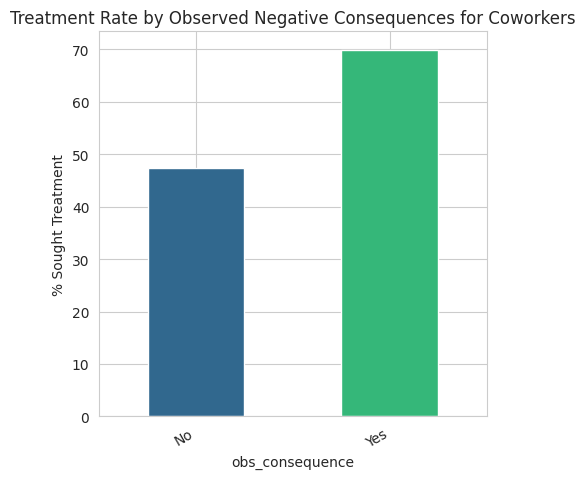

##### 1. Why did you pick the specific chart?
A simple two-category comparison shows whether having witnessed stigma toward coworkers relates to one's own treatment-seeking.

##### 2. What is/are the insight(s) found from the chart?
Respondents who have observed negative consequences for coworkers show a somewhat different treatment rate than those who haven't, suggesting visible stigma events reverberate through the workplace.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative growth insight — observed negative consequences represent a workplace culture risk. Highlighting and addressing incidents when they occur (rather than staying silent) may be important to prevent a chilling effect on others considering treatment.

### Multivariate Analysis

#### Chart - 24 - Correlation Heatmap

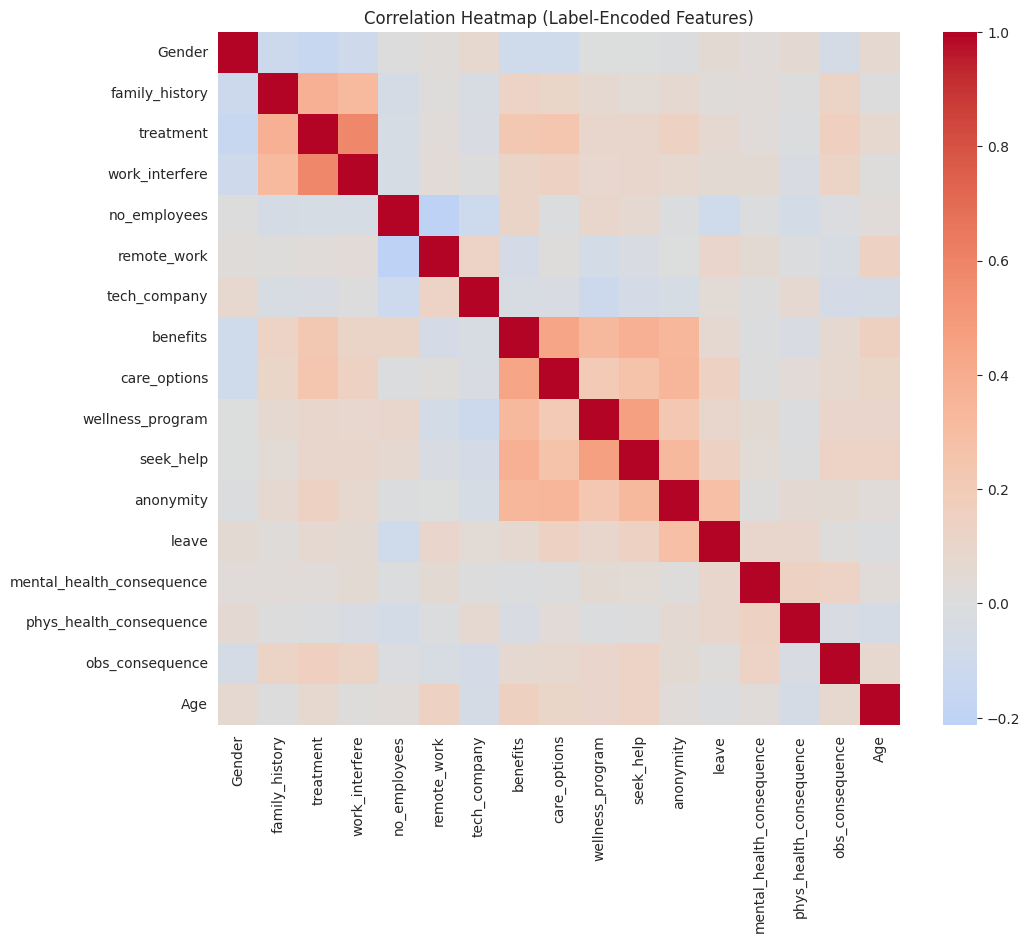

In [ ]:
# Correlation Heatmap visualization code
enc_cols = ['Gender','family_history','treatment','work_interfere','no_employees','remote_work',
            'tech_company','benefits','care_options','wellness_program','seek_help','anonymity',
            'leave','mental_health_consequence','phys_health_consequence','obs_consequence']
df_enc = df[enc_cols + ['Age']].copy()
for c in enc_cols:
    df_enc[c] = LabelEncoder().fit_transform(df_enc[c])

plt.figure(figsize=(11,9))
sns.heatmap(df_enc.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Label-Encoded Features)')
plt.show()

##### 1. Why did you pick the specific chart?
A heatmap over label-encoded versions of the key categorical variables (plus Age) gives a compact overview of how every pair of variables relates to `treatment` and to each other, which would be impossible to inspect one pair at a time.

##### 2. What is/are the insight(s) found from the chart?
`work_interfere` and `family_history` show the strongest correlation with `treatment` among all features, consistent with the bivariate findings above. Age and remote_work show close to zero correlation with treatment. Several workplace-support variables (benefits, care_options, anonymity) show smaller but consistently positive correlations with treatment, reinforcing that they act as a cluster of related "supportive workplace" signals rather than one single dominant factor.

##### 3. Will the gained insights help creating a positive business impact?
Yes — the heatmap confirms that a small number of variables (family history, work interference) should be prioritized for any predictive screening or early-intervention logic, while workplace-support variables should be treated as a bundle of policy levers rather than analyzed in isolation, since they move together.

*(Note: label-encoding is used purely to visualize association strength between categorical variables here — the numeric codes themselves have no ordinal meaning except where the underlying variable is naturally ordered, e.g. `leave`.)*

#### Chart - 25 - Family History × Work Interference → Treatment Rate

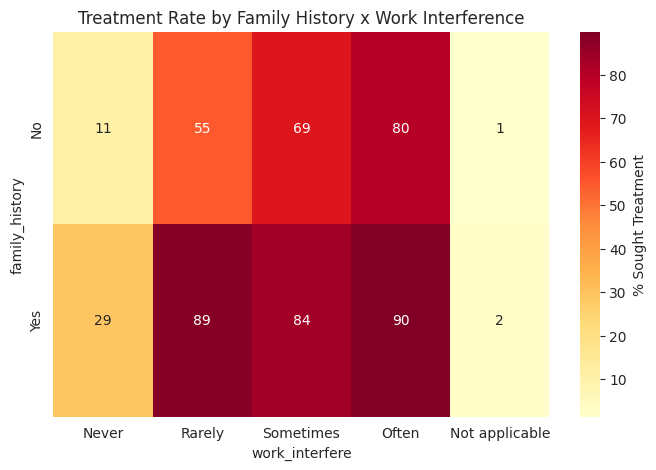

In [ ]:
# Multivariate: Family History x Work Interference -> Treatment Rate heatmap
order_interfere = ['Never','Rarely','Sometimes','Often','Not applicable']
pivot = df.pivot_table(index='family_history', columns='work_interfere', values='treatment',
                        aggfunc=lambda s: (s=='Yes').mean()*100)
pivot = pivot.reindex(columns=order_interfere)

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label':'% Sought Treatment'})
plt.title('Treatment Rate by Family History x Work Interference')
plt.show()

##### 1. Why did you pick the specific chart?
This heatmap combines the two strongest bivariate predictors (family history and work interference) into a single view, showing how they interact rather than assuming their effects simply add up.

##### 2. What is/are the insight(s) found from the chart?
The two factors compound: respondents with both a family history *and* frequent work interference show the highest treatment rates (often 90%+), while those with neither factor show very low rates. Notably, even without a family history, high work interference alone still drives a high treatment rate — suggesting work interference is a strong standalone signal, not just a proxy for family history.

##### 3. Will the gained insights help creating a positive business impact?
Yes — this supports building a simple two-factor early-warning flag (self-reported work interference + optional/voluntary family history disclosure) that HR or an EAP program could use to proactively reach out and offer support, rather than waiting for employees to self-refer.

#### Chart - 26 - Benefits × Care Options → Treatment Rate

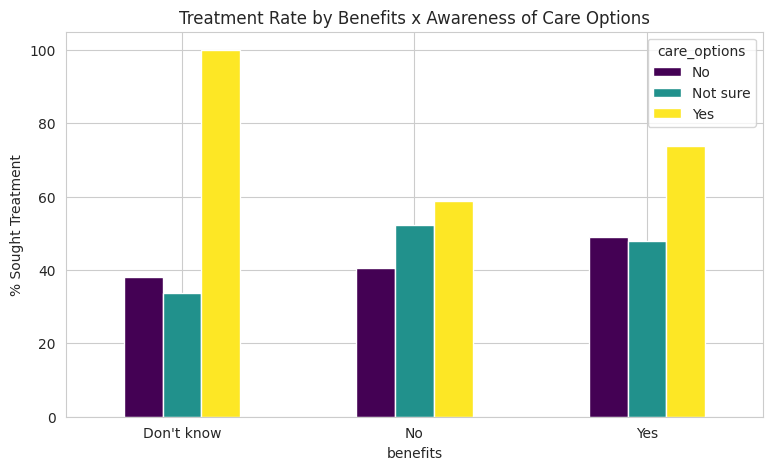

In [ ]:
# Multivariate: Benefits x Care Options -> Treatment Rate grouped bar
pivot2 = df.pivot_table(index='benefits', columns='care_options', values='treatment',
                         aggfunc=lambda s: (s=='Yes').mean()*100)
pivot2.plot(kind='bar', figsize=(9,5), colormap='viridis')
plt.title('Treatment Rate by Benefits x Awareness of Care Options')
plt.ylabel('% Sought Treatment')
plt.xticks(rotation=0)
plt.legend(title='care_options')
plt.show()

##### 1. Why did you pick the specific chart?
A grouped bar chart lets us see whether the effect of employer benefits on treatment-seeking depends on whether the employee is also aware of specific care options, testing for an interaction between two related workplace-support variables.

##### 2. What is/are the insight(s) found from the chart?
The highest treatment rates occur when both `benefits` and `care_options` are `Yes`, confirming these two supports reinforce each other rather than being redundant. Where one is `Yes` but the other is `No`/`Not sure`, treatment rates fall in between, and where both are absent or unknown, rates are lowest.

##### 3. Will the gained insights help creating a positive business impact?
Yes — this suggests employers shouldn't treat "offering benefits" and "communicating specific care options" as interchangeable checkboxes; both need to be in place and clearly communicated together to maximize the effect on treatment-seeking.

#### Chart - 27 - Age × Gender × Treatment

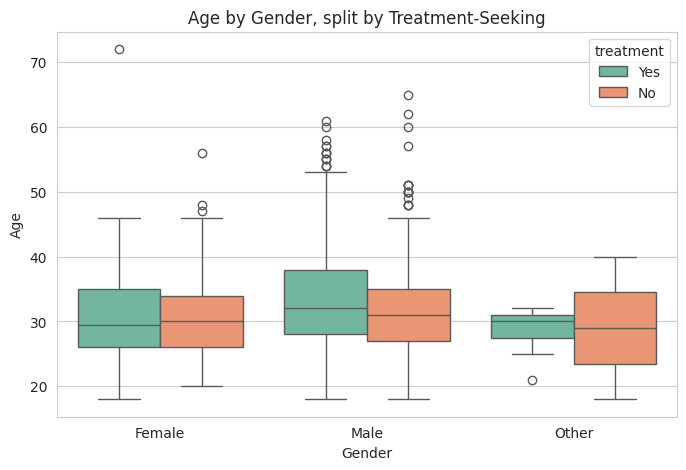

In [ ]:
# Multivariate: Age by Gender, split by Treatment
plt.figure(figsize=(8,5))
sns.boxplot(x='Gender', y='Age', hue='treatment', data=df, palette='Set2')
plt.title('Age by Gender, split by Treatment-Seeking')
plt.show()

##### 1. Why did you pick the specific chart?
A grouped boxplot lets us check whether the (weak) age effect seen earlier behaves differently across gender groups — i.e., whether age matters more for one gender than another.

##### 2. What is/are the insight(s) found from the chart?
Within each gender group, the age distributions for treatment-seekers and non-seekers remain largely similar, mirroring the overall finding that age is not a strong differentiator — this holds consistently across Male, Female, and Other groups, with no evidence of a hidden age effect specific to one gender.

##### 3. Will the gained insights help creating a positive business impact?
Neutral finding, but still useful — it confirms that age-based targeting isn't necessary and that gender-specific outreach (found earlier to matter) doesn't need to be further split by age bracket, simplifying any resulting recommendations.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the EDA, tech employers looking to increase mental-health treatment-seeking and reduce stigma should prioritize, in order of demonstrated impact:

1. **Communicate specific, visible care options and benefits together** — awareness of care options and benefits showed some of the strongest associations with treatment-seeking, and the two reinforce each other. This is a low-cost, high-leverage step (many employers likely already offer some benefit that employees simply don't know about).
2. **Build a light-touch early-warning process around self-reported work interference** — since this is the strongest behavioral signal found, HR/EAP programs could offer a private, voluntary check-in prompt when engagement surveys indicate rising work interference.
3. **Guarantee and clearly communicate anonymity** for anyone using mental-health resources — this was consistently associated with higher treatment rates and directly addresses the stigma gap.
4. **Close the mental-vs-physical stigma gap directly** through manager training and public commitments, since this was the most negative finding: employees clearly perceive far greater risk in disclosing mental health issues than physical ones, which likely suppresses treatment-seeking below what workplace benefits alone would predict.
5. **Extend support to smaller companies**, which show lower treatment rates, likely due to fewer in-house resources — external EAP partnerships can close this gap without requiring a full in-house program.
6. **Design outreach with a gender lens** — since male respondents sought treatment at much lower rates, awareness campaigns may need messaging specifically tailored to reduce a stereotype-driven reluctance to seek help.

# **Conclusion**

This EDA of the OSMI 2014 Mental Health in Tech Survey shows that treatment-seeking is common (just over half of respondents) but far from universal, and it is shaped much more strongly by personal history (family history, self-reported work interference) than by demographics like age. Workplace support factors — benefits, visible care options, wellness programs, anonymity, and ease of leave — are all positively associated with treatment-seeking, forming a coherent cluster of policy levers rather than isolated fixes. At the same time, the data reveals a clear and troubling stigma gap: employees see far more risk in disclosing a mental health issue than a physical one. Any workplace mental-health strategy built on these findings should combine concrete support (benefits + communicated care options + anonymity) with a deliberate effort to close that perception gap, since supportive policy alone may be under-used if the underlying fear of stigma isn't addressed directly.

A companion interactive Streamlit dashboard has been built alongside this notebook, allowing HR stakeholders to filter the data by demographic and workplace variables and explore these relationships live, without needing to read code.

### ***Hurrah! You have successfully completed your EDA Project !!!***